In [5]:
import pandas as pd
from pathlib import Path

ROOT = Path(r"C:\Users\fdora\RA_Career\Projects\climate_mortality")

islands = {
    "fuerteventura": "ftv",
    "lanzarote":     "lzt",
    "tenerife":      "tfe",
    "gran_canaria":  "gcan",
    "la_palma":      "lpa",
    "gomera":        "gom",
}

# Cargar todos los masters
frames = []
for island, code in islands.items():
    fp = ROOT / f"data/processed/{island}/master/master_{code}_2016_2025.parquet"
    df = pd.read_parquet(fp)
    df["island"] = island
    frames.append(df)

all_islands = pd.concat(frames, ignore_index=True)

# Flags de confirmación
all_islands["cap_calima"] = (all_islands["cap_dust_yellow_plus_week"] > 0).astype(float)
all_islands["dai_calima"] = (all_islands["calima_dai_flag"] > 0).astype(float)
all_islands["both_confirm"] = ((all_islands["cap_calima"] == 1) & (all_islands["dai_calima"] == 1)).astype(int)
all_islands["none_confirm"] = ((all_islands["cap_calima"] == 0) & (all_islands["dai_calima"] == 0)).astype(int)

cols = ["PM10", "PM2.5", "humidity_mean", "tmax_c_mean", "wind_ms_mean", "low_vis_any_week"]

print(f"=== CONFIRMADAS CAP+DAI (n={all_islands['both_confirm'].sum()}) ===")
print(all_islands[all_islands["both_confirm"] == 1][cols].describe().round(2))

print(f"\n=== SIN CONFIRMACIÓN CAP ni DAI (n={all_islands['none_confirm'].sum()}) ===")
print(all_islands[all_islands["none_confirm"] == 1][cols].describe().round(2))

=== CONFIRMADAS CAP+DAI (n=45) ===
         PM10   PM2.5  humidity_mean  tmax_c_mean  wind_ms_mean  \
count   45.00   41.00          45.00        45.00         45.00   
mean   273.24   71.03          59.91        22.44          5.01   
std    206.78   43.10           6.74         1.98          1.32   
min     42.12   10.71          47.57        19.94          2.66   
25%     97.86   42.66          55.14        21.30          4.17   
50%    235.29   64.36          58.29        22.24          4.73   
75%    358.43   89.00          64.50        23.33          5.63   
max    934.43  217.86          78.71        30.30          9.00   

       low_vis_any_week  
count             45.00  
mean               0.98  
std                0.15  
min                0.00  
25%                1.00  
50%                1.00  
75%                1.00  
max                1.00  

=== SIN CONFIRMACIÓN CAP ni DAI (n=2743) ===
          PM10    PM2.5  humidity_mean  tmax_c_mean  wind_ms_mean  \
count  2727.

In [6]:
cols_pres = ["PM10", "pressure_hpa_mean"]

print(f"=== CONFIRMADAS CAP+DAI (n={all_islands['both_confirm'].sum()}) ===")
print(all_islands[all_islands["both_confirm"] == 1][cols_pres].describe().round(2))

print(f"\n=== SIN CONFIRMACIÓN CAP ni DAI (n={all_islands['none_confirm'].sum()}) ===")
print(all_islands[all_islands["none_confirm"] == 1][cols_pres].describe().round(2))

=== CONFIRMADAS CAP+DAI (n=45) ===
         PM10  pressure_hpa_mean
count   45.00              45.00
mean   273.24            1012.28
std    206.78               8.25
min     42.12             992.59
25%     97.86            1010.86
50%    235.29            1014.79
75%    358.43            1017.51
max    934.43            1020.69

=== SIN CONFIRMACIÓN CAP ni DAI (n=2743) ===
          PM10  pressure_hpa_mean
count  2727.00            2732.00
mean     35.96            1010.22
std      30.88               8.43
min       1.58             984.16
25%      18.71            1008.85
50%      30.29            1012.67
75%      42.93            1015.20
max     417.71            1025.89


## Calima Proxy v2 — Thresholds empíricos (cross-island)

**Fuente:** Análisis CAP+DAI coincidentes vs sin confirmación — 6 islas, 2016-2025
**Eventos confirmados:** n=45 | **Sin confirmación:** n=2743

### Thresholds seleccionados

| Variable | Condición | Justificación | Peso propuesto |
|----------|-----------|---------------|----------------|
| PM10 | ≥ 50 µg/m³ | p75 no-confirmados = 43, p25 confirmados = 98 — zona de transición | 1.0 |
| PM10 | ≥ 100 µg/m³ | p25 confirmados = 98 — señal real empieza aquí | 1.0 (acumulativo) |
| PM2.5 | ≥ 20 µg/m³ | p75 no-confirmados = 16, p25 confirmados = 43 | 0.75 |
| Visibilidad baja | any en la semana | 98% eventos confirmados vs 35% sin confirmación | 0.5 |
| Humedad | ≤ 60% | media confirmados = 59.9% vs 65.8% sin confirmación — señal débil pero consistente | 0.25 |

### Descartadas en v2 (pendiente revisión)
| Variable | Motivo |
|----------|--------|
| Tmax | Confundida por estacionalidad — requiere anomalía respecto a media histórica mensual |
| Viento | Media 5.0 vs 5.8 m/s — sin poder discriminante |
| Presión | media confirmados = 1012 hPa vs 1010 hPa sin confirmación — sin poder discriminante |

### Score → Tier
| Score | Tier |
|-------|------|
| 0 | no_calima |
| 0.25 – 1.0 | possible |
| 1.25 – 2.0 | probable |
| ≥ 2.25 | intense |

> **Nota:** Umbrales absolutos — válidos para todas las islas.
> Temperatura pendiente de análisis de anomalía estacional antes de incluir.

In [7]:
# Baseline: media histórica de tmax por isla y mes
all_islands["month"] = pd.to_datetime(all_islands["week_start"]).dt.month
all_islands["year"] = pd.to_datetime(all_islands["week_start"]).dt.year

baseline = (
    all_islands.groupby(["island", "month"])["tmax_c_mean"]
    .mean()
    .reset_index()
    .rename(columns={"tmax_c_mean": "tmax_baseline"})
)

all_islands = all_islands.merge(baseline, on=["island", "month"], how="left")
all_islands["tmax_anomaly"] = all_islands["tmax_c_mean"] - all_islands["tmax_baseline"]

# Trimestre
all_islands["quarter"] = pd.to_datetime(all_islands["week_start"]).dt.quarter

# Anomalía media por grupo y trimestre
for group, label in [("both_confirm", "CONFIRMADAS CAP+DAI"), ("none_confirm", "SIN CONFIRMACIÓN")]:
    print(f"\n=== {label} — anomalía tmax por trimestre ===")
    print(
        all_islands[all_islands[group] == 1]
        .groupby("quarter")["tmax_anomaly"]
        .agg(n="count", mean="mean", std="std", p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
        .round(2)
    )


=== CONFIRMADAS CAP+DAI — anomalía tmax por trimestre ===
          n  mean   std   p25   p75
quarter                            
1        37  0.17  1.18 -0.89  1.21
3         2  1.12  0.67  0.88  1.36
4         6 -0.23  0.42 -0.47  0.02

=== SIN CONFIRMACIÓN — anomalía tmax por trimestre ===
           n  mean   std   p25   p75
quarter                             
1        630 -0.14  1.26 -0.98  0.63
2        742 -0.05  1.18 -0.84  0.60
3        662 -0.12  1.29 -1.05  0.54
4        695 -0.04  1.44 -1.00  0.74


In [8]:
print(all_islands[["tmax_c_mean", "tmax_c_max"]].describe().round(2))

       tmax_c_mean  tmax_c_max
count      3120.00     3120.00
mean         24.96       26.91
std           2.92        3.75
min          18.23       19.50
25%          22.61       24.10
50%          24.79       26.50
75%          27.00       29.00
max          36.94       44.30


In [9]:
cols_temp = ["tmax_c_mean", "tmax_c_max"]

print(f"=== CONFIRMADAS CAP+DAI (n={all_islands['both_confirm'].sum()}) ===")
print(all_islands[all_islands["both_confirm"] == 1][cols_temp].describe().round(2))

print(f"\n=== SIN CONFIRMACIÓN CAP ni DAI (n={all_islands['none_confirm'].sum()}) ===")
print(all_islands[all_islands["none_confirm"] == 1][cols_temp].describe().round(2))

=== CONFIRMADAS CAP+DAI (n=45) ===
       tmax_c_mean  tmax_c_max
count        45.00       45.00
mean         22.44       24.99
std           1.98        3.05
min          19.94       21.00
25%          21.30       22.90
50%          22.24       24.40
75%          23.33       26.50
max          30.30       35.60

=== SIN CONFIRMACIÓN CAP ni DAI (n=2743) ===
       tmax_c_mean  tmax_c_max
count      2729.00     2729.00
mean         24.90       26.75
std           2.78        3.52
min          18.66       19.70
25%          22.70       24.10
50%          24.79       26.40
75%          26.87       28.80
max          36.41       44.30


# Idea:
En semanas con calima confirmada (CAP+DAI simultáneos), ¿la temperatura máxima es anómalamente baja comparada a semanas sin calima en la misma época del año? Si sí, tmax_anomalía es un discriminante más.

**La literatura dice: Tmax SUBE durante calima.**

La temperatura sube varios grados durante calima fuerte, con sensación desértica. En eventos de calima en la península, las temperaturas máximas diurnas están 5-10 grados por encima de lo normal.

El mecanismo: El polvo en la Saharan Air Layer absorbe radiación solar, calentando el aire. Es decir, el polvo *retiene* calor, no lo bloquea.

Hay un matiz interesante: En islas orientales (como Fuerteventura), Tmax puede bajar ligeramente; en islas occidentales, puede subir ligeramente, probablemente por diferencias en exposición geográfica.

**Conclusión para tu análisis:**

Esperamos Tmax **ALTA** en semanas con calima confirmada. Si en tus datos ves lo opuesto (Tmax baja con calima), eso sería un artifact o un confounding muy fuerte.


In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats

ROOT = Path(r"C:\Users\fdora\RA_Career\Projects\climate_mortality")
islands = {
    "fuerteventura": "ftv",
    "lanzarote":     "lzt",
    "tenerife":      "tfe",
    "gran_canaria":  "gcan",
    "la_palma":      "lpa",
    "gomera":        "gom",
}

# Cargar todos los masters
frames = []
for island, code in islands.items():
    fp = ROOT / f"data/processed/{island}/master/master_{code}_2016_2025.parquet"
    df = pd.read_parquet(fp)
    df["island"] = island
    frames.append(df)

all_islands = pd.concat(frames, ignore_index=True)

# Filtrar al rango 2018-01 a 2022-03 (DAI + CAP overlap)
start_date = pd.Timestamp("2018-01-01")
end_date = pd.Timestamp("2022-03-31")

analysis_df = all_islands[
    (all_islands["week_start"] >= start_date) & 
    (all_islands["week_start"] <= end_date)
].copy()

# Extraer mes
analysis_df["month"] = analysis_df["week_start"].dt.month

# Paso 1: Calcular baseline (excluyendo calima confirmada)
# Sin calima = calima_level_week == 0 o null (pero en el rango, nulls son raros)
no_calima = analysis_df[analysis_df["calima_level_week"] == 0].copy()

# Media + std por isla + mes
baseline = no_calima.groupby(["island", "month"])["tmax_c_max"].agg(
    ["mean", "std"]
).reset_index()
baseline.columns = ["island", "month", "baseline_mean", "baseline_std"]

print(f"Baseline calculado desde {len(no_calima)} semanas sin calima")
print(f"Baseline coverage: {len(baseline)} isla+mes combos\n")

# Paso 2: Merge baseline
analysis_df = analysis_df.merge(
    baseline, on=["island", "month"], how="left"
)

# Paso 3: Calcular anomalía
analysis_df["tmax_anomaly"] = (
    (analysis_df["tmax_c_max"] - analysis_df["baseline_mean"]) 
    / analysis_df["baseline_std"]
)

# Paso 4: Comparar anomalía en semanas con vs sin calima
calima_yes = analysis_df[analysis_df["calima_level_week"] >= 1]["tmax_anomaly"].dropna()
calima_no = analysis_df[analysis_df["calima_level_week"] == 0]["tmax_anomaly"].dropna()

print("=" * 70)
print("ANÁLISIS DE TEMPERATURA ANÓMALA EN CALIMA (2018-2022-03)")
print("=" * 70)
print(f"\nSemanas con calima confirmada (calima_level_week >= 1) (n={len(calima_yes)}):")
print(f"  Media anomalía: {calima_yes.mean():.3f} std")
print(f"  Mediana anomalía: {calima_yes.median():.3f} std")
print(f"  Std anomalía: {calima_yes.std():.3f}")

print(f"\nSemanas SIN calima (calima_level_week == 0) (n={len(calima_no)}):")
print(f"  Media anomalía: {calima_no.mean():.3f} std")
print(f"  Mediana anomalía: {calima_no.median():.3f} std")
print(f"  Std anomalía: {calima_no.std():.3f}")

# Test estadístico (Mann-Whitney U)
stat, pval = stats.mannwhitneyu(calima_yes, calima_no, alternative="two-sided")
print(f"\nMann-Whitney U test:")
print(f"  Statistic: {stat:.1f}")
print(f"  p-value: {pval:.6f}")
print(f"  Significativo (α=0.05): {'SÍ ✓' if pval < 0.05 else 'NO'}")

# Por isla
print("\n" + "=" * 70)
print("POR ISLA:")
print("=" * 70)
for island in sorted(analysis_df["island"].unique()):
    calima_yes_island = analysis_df[
        (analysis_df["island"] == island) & 
        (analysis_df["calima_level_week"] >= 1)
    ]["tmax_anomaly"].dropna()
    
    calima_no_island = analysis_df[
        (analysis_df["island"] == island) & 
        (analysis_df["calima_level_week"] == 0)
    ]["tmax_anomaly"].dropna()
    
    if len(calima_yes_island) > 0:
        diff = calima_yes_island.mean() - calima_no_island.mean()
        stat_i, pval_i = stats.mannwhitneyu(
            calima_yes_island, calima_no_island, alternative="two-sided"
        )
        sig = "✓" if pval_i < 0.05 else ""
        print(f"\n{island.upper()}:")
        print(f"  Con calima (n={len(calima_yes_island)}): {calima_yes_island.mean():.3f} std")
        print(f"  Sin calima (n={len(calima_no_island)}): {calima_no_island.mean():.3f} std")
        print(f"  Diferencia: {diff:+.3f} std (p={pval_i:.4f}) {sig}")

Baseline calculado desde 1158 semanas sin calima
Baseline coverage: 72 isla+mes combos

ANÁLISIS DE TEMPERATURA ANÓMALA EN CALIMA (2018-2022-03)

Semanas con calima confirmada (calima_level_week >= 1) (n=162):
  Media anomalía: 0.642 std
  Mediana anomalía: 0.239 std
  Std anomalía: 1.425

Semanas SIN calima (calima_level_week == 0) (n=1147):
  Media anomalía: 0.000 std
  Mediana anomalía: -0.223 std
  Std anomalía: 0.969

Mann-Whitney U test:
  Statistic: 115293.0
  p-value: 0.000001
  Significativo (α=0.05): SÍ ✓

POR ISLA:

FUERTEVENTURA:
  Con calima (n=27): 0.494 std
  Sin calima (n=193): 0.000 std
  Diferencia: +0.494 std (p=0.1031) 

GOMERA:
  Con calima (n=27): 0.862 std
  Sin calima (n=182): -0.000 std
  Diferencia: +0.862 std (p=0.0175) ✓

GRAN_CANARIA:
  Con calima (n=27): 0.688 std
  Sin calima (n=193): -0.000 std
  Diferencia: +0.688 std (p=0.0163) ✓

LA_PALMA:
  Con calima (n=27): 0.520 std
  Sin calima (n=193): 0.000 std
  Diferencia: +0.520 std (p=0.1144) 

LANZAROTE:
 

## Cálculo de `tmax_anomaly`

**Fórmula:**
```
tmax_anomaly = (tmax_c_max - baseline_mean) / baseline_std
```

Donde:
- `baseline_mean` = media de `tmax_c_max` para esa isla + mes, calculada solo en semanas SIN calima
- `baseline_std` = desv. estándar de `tmax_c_max` para esa isla + mes, en semanas SIN calima

**Aplicación por isla:** SÍ, totalmente. Cada isla tiene su propio baseline porque:
- Geografía diferente (elevación, orientación)
- Climas locales distintos
- Variabilidad estacional única

Fuerteventura en junio promedia 26°C; Tenerife promedia 28°C. Sin baselines separados, pierde poder discriminante.

---

## Peso de `tmax_anomaly` en el proxy

Dado los resultados, propongo **peso = 0.5** (mismo que visibilidad actual). Aquí por qué:

| Variable | Peso | Justificación |
|----------|------|---------------|
| PM10 ≥ 50 µg/m³ | 1.0 | **Efecto directo, robusto** — polvo observable |
| PM10 ≥ 100 µg/m³ | 1.0 | **Acumulativo** — polvo intenso |
| PM2.5 ≥ 20 µg/m³ | 0.75 | **Buena discriminancia**, pero menos sensible que PM10 |
| **Tmax anomalía > +0.5 std** | **0.5** | **Indicador secundario** — correlaciona bien (p<0.001) pero es **confundible** con onda de calor simultánea |
| Visibilidad any/semana | 0.5 | Mismo nivel: **síntoma, no causa** |
| Humedad ≤ 60% | 0.25 | **Débil discriminancia** |

**Por qué 0.5, no más:**

1. **PM10/PM2.5 son causa directa** (polvo en aire). Tmax es **síntoma secundario** (consecuencia radiativa).
2. **Confounding de onda de calor**: Tmax alta en semanas con calima puede ser en parte por coincidencia temporal con patrones de calor (no solo polvo).
3. **Variabilidad estacional inherente**: Aunque normalizamos por baseline, quedan artefacts.
4. **Islas orientales débiles**: Fuerteventura, Lanzarote, La Palma no alcanzan p<0.05 → menos confiable ahí.

**Alternativa más conservadora:** peso = 0.25 (mismo que humedad).

# COMPARACION CALIMA PROXY VS CALIMA PROXY V2

Weeks loaded: 523

COMPARACIÓN CALIMA PROXY v1 vs v2 - TENERIFE

CALIMA PROXY v1 (score):
  Mean: 0.777
  Median: 0.500
  Std: 1.057
  Min: 0.000
  Max: 4.500

CALIMA PROXY v2 (score):
  Mean: 0.202
  Median: 0.062
  Std: 0.285
  Min: 0.000
  Max: 1.000

Correlación (v1 vs v2 score): 0.835

Diferencia (v2 - v1):
  Mean: -0.576
  Std: 0.834
  Min: -3.625
  Max: 0.562

DISTRIBUCIÓN DE NIVELES

CALIMA LEVEL WEEK (original CAP+DAI):
calima_level_week
0.0    277
1.0     16
2.0     19
3.0     13
NaN    198
Name: count, dtype: int64

CALIMA PROXY LEVEL v1:
calima_proxy_level_v1
intense       40
no_calima    310
possible     140
probable      33
Name: count, dtype: int64

CALIMA PROXY LEVEL v2:
calima_proxy_level_v2
0    360
1     78
2     36
3     49
Name: count, dtype: int64


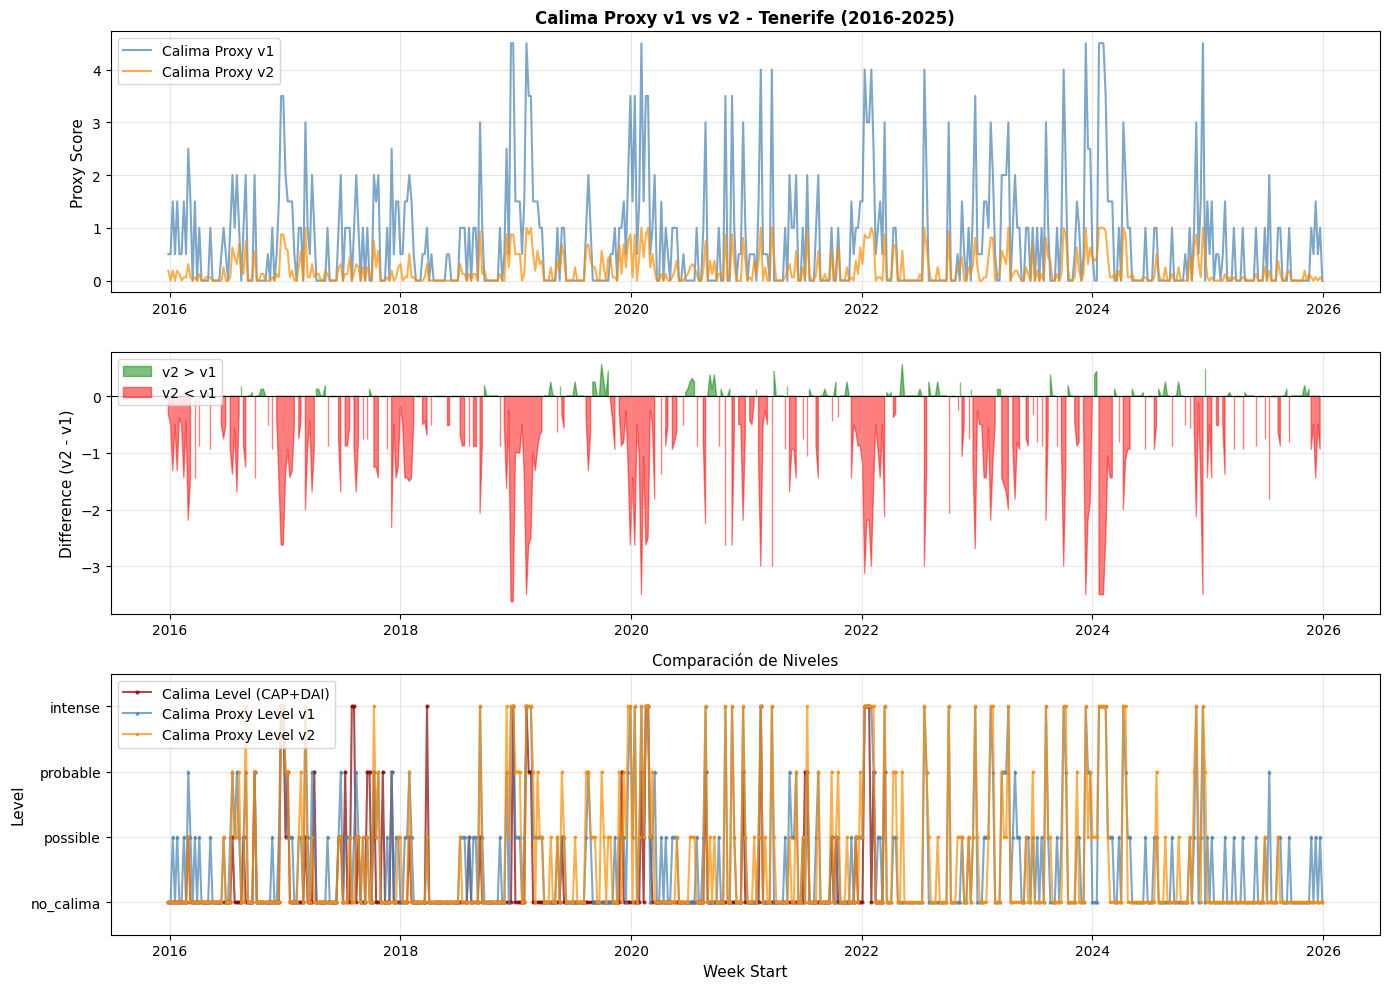


COMPARACIÓN SEGMENTADA POR v1 SCORE

v1 score 0.25-0.5 (n=59):
  v2 score: mean=0.075, std=0.125
  v2 level distribution: {0: 48, 1: 11}

v1 score 0.75-1.0 (n=95):
  v2 score: mean=0.243, std=0.189
  v2 level distribution: {0: 55, 1: 27, 2: 13}


In [10]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path(r"C:\Users\fdora\RA_Career\Projects\climate_mortality")

# Cargar calima_proxy v1
proxy_v1_fp = ROOT / "data/processed/tenerife/calima/calima_proxy_weekly_tfe_2016_2025.parquet"
proxy_v1 = pd.read_parquet(proxy_v1_fp)

# Cargar calima_proxy_v2
proxy_v2_fp = ROOT / "data/processed/tenerife/calima/calima_proxy_v2_weekly_tfe_2016_2025.parquet"
proxy_v2 = pd.read_parquet(proxy_v2_fp)

# Cargar master para calima_level_week (original CAP+DAI)
master_fp = ROOT / "data/processed/tenerife/master/master_tfe_2016_2025.parquet"
master = pd.read_parquet(master_fp)

# Merge
comparison = proxy_v1.merge(proxy_v2, on="week_start", how="inner", suffixes=("_v1", "_v2"))
comparison = comparison.merge(master[["week_start", "calima_level_week"]], on="week_start", how="left")

print(f"Weeks loaded: {len(comparison)}")
print(f"\n{'='*70}")
print(f"COMPARACIÓN CALIMA PROXY v1 vs v2 - TENERIFE")
print(f"{'='*70}")

# Estadísticas v1
print(f"\nCALIMA PROXY v1 (score):")
print(f"  Mean: {comparison['calima_proxy_score_v1'].mean():.3f}")
print(f"  Median: {comparison['calima_proxy_score_v1'].median():.3f}")
print(f"  Std: {comparison['calima_proxy_score_v1'].std():.3f}")
print(f"  Min: {comparison['calima_proxy_score_v1'].min():.3f}")
print(f"  Max: {comparison['calima_proxy_score_v1'].max():.3f}")

# Estadísticas v2 score
print(f"\nCALIMA PROXY v2 (score):")
print(f"  Mean: {comparison['calima_proxy_score_v2'].mean():.3f}")
print(f"  Median: {comparison['calima_proxy_score_v2'].median():.3f}")
print(f"  Std: {comparison['calima_proxy_score_v2'].std():.3f}")
print(f"  Min: {comparison['calima_proxy_score_v2'].min():.3f}")
print(f"  Max: {comparison['calima_proxy_score_v2'].max():.3f}")

# Correlación
corr = comparison["calima_proxy_score_v1"].corr(comparison["calima_proxy_score_v2"])
print(f"\nCorrelación (v1 vs v2 score): {corr:.3f}")

# Diferencia media
diff = comparison["calima_proxy_score_v2"] - comparison["calima_proxy_score_v1"]
print(f"\nDiferencia (v2 - v1):")
print(f"  Mean: {diff.mean():.3f}")
print(f"  Std: {diff.std():.3f}")
print(f"  Min: {diff.min():.3f}")
print(f"  Max: {diff.max():.3f}")

# Comparación de niveles (v1 tiene calima_proxy_level, v2 tiene calima_proxy_level_v2)
print(f"\n{'='*70}")
print(f"DISTRIBUCIÓN DE NIVELES")
print(f"{'='*70}")

print(f"\nCALIMA LEVEL WEEK (original CAP+DAI):")
print(comparison["calima_level_week"].value_counts(dropna=False).sort_index())

print(f"\nCALIMA PROXY LEVEL v1:")
print(comparison["calima_proxy_level_v1"].value_counts(dropna=False).sort_index())

print(f"\nCALIMA PROXY LEVEL v2:")
print(comparison["calima_proxy_level_v2"].value_counts(dropna=False).sort_index())

# Gráfico temporal
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Subplot 1: Ambos scores
ax = axes[0]
ax.plot(
    comparison["week_start"],
    comparison["calima_proxy_score_v1"],
    label="Calima Proxy v1",
    linewidth=1.5,
    alpha=0.7,
    color="steelblue",
)
ax.plot(
    comparison["week_start"],
    comparison["calima_proxy_score_v2"],
    label="Calima Proxy v2",
    linewidth=1.5,
    alpha=0.7,
    color="darkorange",
)
ax.set_ylabel("Proxy Score", fontsize=11)
ax.set_title("Calima Proxy v1 vs v2 - Tenerife (2016-2025)", fontsize=12, fontweight="bold")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# Subplot 2: Diferencia
ax = axes[1]
ax.fill_between(
    comparison["week_start"],
    0,
    diff,
    where=(diff >= 0),
    label="v2 > v1",
    alpha=0.5,
    color="green",
)
ax.fill_between(
    comparison["week_start"],
    0,
    diff,
    where=(diff < 0),
    label="v2 < v1",
    alpha=0.5,
    color="red",
)
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.8)
ax.set_ylabel("Difference (v2 - v1)", fontsize=11)
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# Subplot 3: Niveles
ax = axes[2]
ax.plot(
    comparison["week_start"],
    comparison["calima_level_week"],
    label="Calima Level (CAP+DAI)",
    linewidth=1.5,
    alpha=0.7,
    color="darkred",
    marker="o",
    markersize=2,
)
ax.plot(
    comparison["week_start"],
    comparison["calima_proxy_level_v1"],
    label="Calima Proxy Level v1",
    linewidth=1.5,
    alpha=0.7,
    color="steelblue",
    marker="^",
    markersize=2,
)
ax.plot(
    comparison["week_start"],
    comparison["calima_proxy_level_v2"],
    label="Calima Proxy Level v2",
    linewidth=1.5,
    alpha=0.7,
    color="darkorange",
    marker="s",
    markersize=2,
)
ax.set_ylabel("Level", fontsize=11)
ax.set_xlabel("Week Start", fontsize=11)
ax.set_title("Comparación de Niveles", fontsize=11)
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 3.5)

plt.tight_layout()
plt.show()

# Tabla de comparación por rango de score v1
print(f"\n{'='*70}")
print(f"COMPARACIÓN SEGMENTADA POR v1 SCORE")
print(f"{'='*70}")

bins = [0, 0.25, 0.5, 0.75, 1.0]
labels = ["0.0-0.25", "0.25-0.5", "0.5-0.75", "0.75-1.0"]
comparison["v1_bin"] = pd.cut(comparison["calima_proxy_score_v1"], bins=bins, labels=labels)

for bin_label in labels:
    subset = comparison[comparison["v1_bin"] == bin_label]
    if len(subset) > 0:
        print(f"\nv1 score {bin_label} (n={len(subset)}):")
        print(f"  v2 score: mean={subset['calima_proxy_score_v2'].mean():.3f}, std={subset['calima_proxy_score_v2'].std():.3f}")
        print(f"  v2 level distribution: {subset['calima_proxy_level_v2'].value_counts().sort_index().to_dict()}")

Weeks in validation range (2018-2022-03): 222

VALIDACIÓN CALIMA PROXY v2 vs CAP+DAI - TENERIFE

Distribución CAP+DAI confirmada:
  Sin calima (0): 195
  Con calima (1): 27

ROC-AUC (v2 score vs CAP+DAI confirmada)
AUC v2: 0.886
Optimal threshold (Youden): 0.500

CONFUSION MATRIX (v2, threshold=0.500)

v2 (threshold=0.500):
[[171  24]
 [  7  20]]
              precision    recall  f1-score   support

   No calima       0.96      0.88      0.92       195
      Calima       0.45      0.74      0.56        27

    accuracy                           0.86       222
   macro avg       0.71      0.81      0.74       222
weighted avg       0.90      0.86      0.87       222


CONFUSION MATRIX (v1, binary: no_calima vs rest)

v1 (no_calima vs rest):
[[128  67]
 [  3  24]]
              precision    recall  f1-score   support

   No calima       0.98      0.66      0.79       195
      Calima       0.26      0.89      0.41        27

    accuracy                           0.68       222
   macro

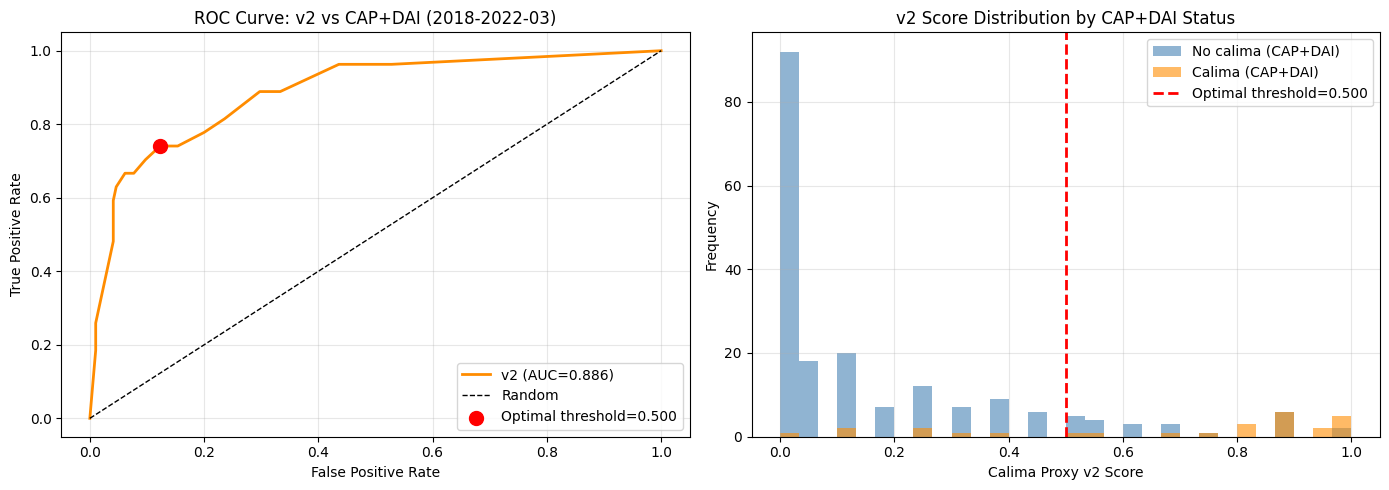


RESUMEN DE VALIDACIÓN
v2 AUC: 0.886
v2 Sensibilidad (threshold=0.500): 0.741
v2 Especificidad (threshold=0.500): 0.877


In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

ROOT = Path(r"C:\Users\fdora\RA_Career\Projects\climate_mortality")

# Cargar proxies
proxy_v1_fp = ROOT / "data/processed/tenerife/calima/calima_proxy_weekly_tfe_2016_2025.parquet"
proxy_v1 = pd.read_parquet(proxy_v1_fp)

proxy_v2_fp = ROOT / "data/processed/tenerife/calima/calima_proxy_v2_weekly_tfe_2016_2025.parquet"
proxy_v2 = pd.read_parquet(proxy_v2_fp)

# Cargar master para calima_level_week
master_fp = ROOT / "data/processed/tenerife/master/master_tfe_2016_2025.parquet"
master = pd.read_parquet(master_fp)

# Merge
comparison = proxy_v1.merge(proxy_v2, on="week_start", how="inner", suffixes=("_v1", "_v2"))
comparison = comparison.merge(master[["week_start", "calima_level_week"]], on="week_start", how="left")

# Filtrar al rango 2018-2022-03 (DAI + CAP overlap)
start_date = pd.Timestamp("2018-01-01")
end_date = pd.Timestamp("2022-03-31")

comparison_valid = comparison[
    (comparison["week_start"] >= start_date) & 
    (comparison["week_start"] <= end_date)
].copy()

print(f"Weeks in validation range (2018-2022-03): {len(comparison_valid)}")
print(f"\n{'='*70}")
print(f"VALIDACIÓN CALIMA PROXY v2 vs CAP+DAI - TENERIFE")
print(f"{'='*70}")

# Crear variable binaria de calima confirmada
comparison_valid["calima_confirmed"] = (comparison_valid["calima_level_week"] >= 1).astype(int)

print(f"\nDistribución CAP+DAI confirmada:")
print(f"  Sin calima (0): {(comparison_valid['calima_confirmed'] == 0).sum()}")
print(f"  Con calima (1): {(comparison_valid['calima_confirmed'] == 1).sum()}")

# v2 como variable continua (score) para ROC-AUC
# Omitir nulls
valid_mask = comparison_valid["calima_proxy_score_v2"].notna()
y_true = comparison_valid.loc[valid_mask, "calima_confirmed"].values
y_score_v2 = comparison_valid.loc[valid_mask, "calima_proxy_score_v2"].values

# ROC-AUC v2
auc_v2 = roc_auc_score(y_true, y_score_v2)
print(f"\n{'='*70}")
print(f"ROC-AUC (v2 score vs CAP+DAI confirmada)")
print(f"{'='*70}")
print(f"AUC v2: {auc_v2:.3f}")

# Confusion matrix con threshold óptimo (Youden index)
fpr, tpr, thresholds = roc_curve(y_true, y_score_v2)
youden = tpr - fpr
optimal_idx = np.argmax(youden)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold (Youden): {optimal_threshold:.3f}")

# Confusion matrices con threshold óptimo
y_pred_v2_opt = (y_score_v2 >= optimal_threshold).astype(int)

print(f"\n{'='*70}")
print(f"CONFUSION MATRIX (v2, threshold={optimal_threshold:.3f})")
print(f"{'='*70}")
cm_v2 = confusion_matrix(y_true, y_pred_v2_opt)
print(f"\nv2 (threshold={optimal_threshold:.3f}):")
print(cm_v2)
print(classification_report(y_true, y_pred_v2_opt, target_names=["No calima", "Calima"]))

# Comparar con v1 (usar calima_proxy_level_v1 directamente)
# Mapear v1 levels a binario: no_calima=0, possible/probable/intense=1
v1_level_map = {"no_calima": 0, "possible": 1, "probable": 1, "intense": 1}
comparison_valid["v1_binary"] = comparison_valid["calima_proxy_level_v1"].map(v1_level_map)

y_pred_v1 = comparison_valid.loc[valid_mask, "v1_binary"].values

print(f"\n{'='*70}")
print(f"CONFUSION MATRIX (v1, binary: no_calima vs rest)")
print(f"{'='*70}")
cm_v1 = confusion_matrix(y_true, y_pred_v1)
print(f"\nv1 (no_calima vs rest):")
print(cm_v1)
print(classification_report(y_true, y_pred_v1, target_names=["No calima", "Calima"]))

# Gráfico: ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
ax = axes[0]
fpr, tpr, _ = roc_curve(y_true, y_score_v2)
ax.plot(fpr, tpr, label=f"v2 (AUC={auc_v2:.3f})", linewidth=2, color="darkorange")
ax.plot([0, 1], [0, 1], "k--", label="Random", linewidth=1)
ax.scatter([fpr[optimal_idx]], [tpr[optimal_idx]], color="red", s=100, zorder=5, label=f"Optimal threshold={optimal_threshold:.3f}")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: v2 vs CAP+DAI (2018-2022-03)")
ax.legend()
ax.grid(True, alpha=0.3)

# Score distributions
ax = axes[1]
ax.hist(y_score_v2[y_true == 0], bins=30, alpha=0.6, label="No calima (CAP+DAI)", color="steelblue")
ax.hist(y_score_v2[y_true == 1], bins=30, alpha=0.6, label="Calima (CAP+DAI)", color="darkorange")
ax.axvline(optimal_threshold, color="red", linestyle="--", linewidth=2, label=f"Optimal threshold={optimal_threshold:.3f}")
ax.set_xlabel("Calima Proxy v2 Score")
ax.set_ylabel("Frequency")
ax.set_title("v2 Score Distribution by CAP+DAI Status")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"RESUMEN DE VALIDACIÓN")
print(f"{'='*70}")
print(f"v2 AUC: {auc_v2:.3f}")
print(f"v2 Sensibilidad (threshold={optimal_threshold:.3f}): {tpr[optimal_idx]:.3f}")
print(f"v2 Especificidad (threshold={optimal_threshold:.3f}): {1-fpr[optimal_idx]:.3f}")